# 🏦 CIBC Banking Analytics Dashboard
## Phase 5: Exploratory Data Analysis & Visualizations

**Author:** Your Name  
**Dataset:** Credit Card Customer Attrition (Kaggle)  
**Records:** 8,418 cleaned records | 28 features  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---

### 📋 Project Overview
This notebook performs a comprehensive exploratory data analysis (EDA) 
on CIBC's credit card customer portfolio. The goal is to identify key 
drivers of customer churn and provide actionable insights for the 
retention team.

### 🎯 Key Business Questions
1. What is the overall churn rate across the portfolio?
2. Which provinces have the highest churn risk?
3. Do card category and income level influence churn?
4. How does transaction behaviour differ between churned and retained customers?
5. What customer segments are highest risk?

In [4]:
# ── Imports & Configuration ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# CIBC Brand Colors
CIBC_RED  = '#C41F3E'
CIBC_NAVY = '#1A1A2E'
CIBC_GREY = '#F5F5F5'
CIBC_GOLD = '#B8860B'
WHITE     = '#FFFFFF'

# Global plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.facecolor'   : WHITE,
    'figure.facecolor' : CIBC_GREY,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : CIBC_NAVY,
    'axes.labelcolor'  : CIBC_NAVY,
    'xtick.color'      : CIBC_NAVY,
    'ytick.color'      : CIBC_NAVY,
})

os.makedirs('../screenshots', exist_ok=True)
print("✅ Libraries loaded & CIBC theme configured")

✅ Libraries loaded & CIBC theme configured


---
## 1️⃣ Data Loading & Overview
Loading the cleaned dataset produced in Phase 2.

In [5]:
# ── Load Cleaned Data ─────────────────────────────────────────
df = pd.read_csv('../data/cleaned/cibc_cleaned.csv')

print(f"{'='*50}")
print(f"  CIBC CREDIT CARD DATASET — OVERVIEW")
print(f"{'='*50}")
print(f"  Total Records  : {len(df):,}")
print(f"  Total Features : {df.shape[1]}")
print(f"  Churned        : {df['churn_flag'].sum():,} ({df['churn_flag'].mean()*100:.1f}%)")
print(f"  Retained       : {(df['churn_flag']==0).sum():,} ({(1-df['churn_flag'].mean())*100:.1f}%)")
print(f"  Avg Credit Limit: ${df['credit_limit'].mean():,.0f}")
print(f"  Avg Transaction : ${df['total_trans_amt'].mean():,.0f}")
print(f"{'='*50}")

df.head()

  CIBC CREDIT CARD DATASET — OVERVIEW
  Total Records  : 8,418
  Total Features : 26
  Churned        : 1,391 (16.5%)
  Retained       : 7,027 (83.5%)
  Avg Credit Limit: $5,908
  Avg Transaction : $3,460


,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,...,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,province,age_group,credit_tier,transaction_segment,churn_flag,utilization_category
0,Retained,45,Male,3,High School,Married,$60K - $80K,CIBC Classic,39,5,...,1144,42,1.625,0.061,Quebec,36-45,Premium ($10-20K),Medium,0,Very Low (<10%)
1,Retained,49,Female,5,Graduate,Single,Less than $40K,CIBC Classic,44,6,...,1291,33,3.714,0.105,Nova Scotia,46-55,Standard ($5-10K),Medium,0,Low (10-30%)
2,Retained,51,Male,3,Graduate,Married,$80K - $120K,CIBC Classic,36,4,...,1887,20,2.333,0.000,British Columbia,46-55,Entry ($0-5K),Low,0,Very Low (<10%)
3,Retained,40,Female,4,High School,Unknown,Less than $40K,CIBC Classic,34,3,...,1171,20,2.333,0.760,British Columbia,36-45,Entry ($0-5K),Low,0,High (>60%)
4,Retained,40,Male,3,Uneducated,Married,$60K - $80K,CIBC Classic,21,5,...,816,28,2.500,0.000,Ontario,36-45,Entry ($0-5K),Low,0,Very Low (<10%)


---
## 2️⃣ Overall Churn Distribution
> **Key Finding:** Approximately 1 in 6 CIBC credit card customers 
> churned. This ~16.5% churn rate represents significant revenue risk 
> and highlights the need for proactive retention strategies.

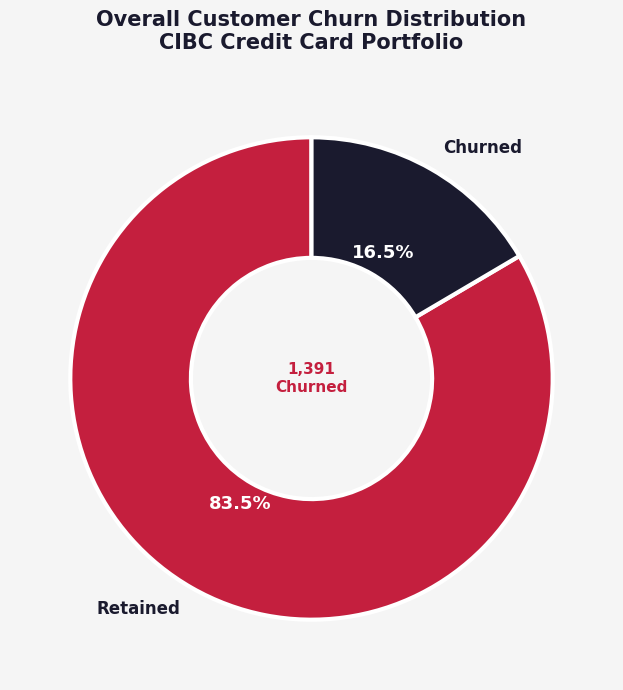

In [6]:
# ── Plot 1: Churn Distribution Donut ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(CIBC_GREY)

churn_counts = df['attrition_flag'].value_counts()
wedges, texts, autotexts = ax.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=[CIBC_RED, CIBC_NAVY],
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3),
    textprops=dict(color=CIBC_NAVY, fontsize=12, fontweight='bold')
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Overall Customer Churn Distribution\nCIBC Credit Card Portfolio',
             fontsize=15, fontweight='bold', color=CIBC_NAVY, pad=20)
ax.add_patch(plt.Circle((0,0), 0.25, color=CIBC_GREY))
ax.text(0, 0, f"{churn_counts['Churned']:,}\nChurned",
        ha='center', va='center', fontsize=11,
        fontweight='bold', color=CIBC_RED)

plt.tight_layout()
plt.savefig('../screenshots/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3️⃣ Geographic Analysis — Churn by Province
> **Key Finding:** Churn rates are relatively consistent across 
> provinces (15-18%), suggesting churn is driven by customer behaviour 
> rather than regional factors. Nova Scotia shows slightly elevated risk 
> worth monitoring.

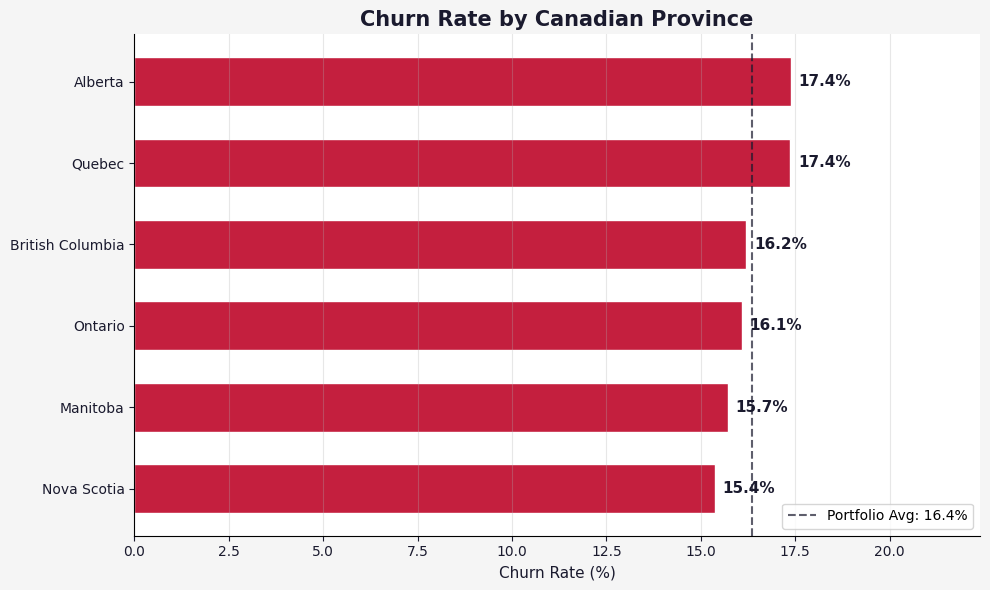

In [7]:
# ── Plot 2: Churn by Province ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(CIBC_GREY)

prov_churn = (df.groupby('province')['churn_flag']
              .mean().sort_values(ascending=True) * 100)

bars = ax.barh(prov_churn.index, prov_churn.values,
               color=CIBC_RED, edgecolor='white', height=0.6)

for bar, val in zip(bars, prov_churn.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11,
            fontweight='bold', color=CIBC_NAVY)

ax.axvline(prov_churn.mean(), color=CIBC_NAVY, linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'Portfolio Avg: {prov_churn.mean():.1f}%')

ax.set_title('Churn Rate by Canadian Province', fontsize=15, fontweight='bold')
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, prov_churn.max() + 5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../screenshots/02_churn_by_province.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4️⃣ Card Category Analysis
> **Key Finding:** CIBC Platinum cardholders show a dramatically higher 
> churn rate (66.67%) — however this segment has only 3 customers, 
> making it statistically unreliable. CIBC Gold (19%) and Classic (16.5%) 
> are the most meaningful segments to target for retention campaigns.

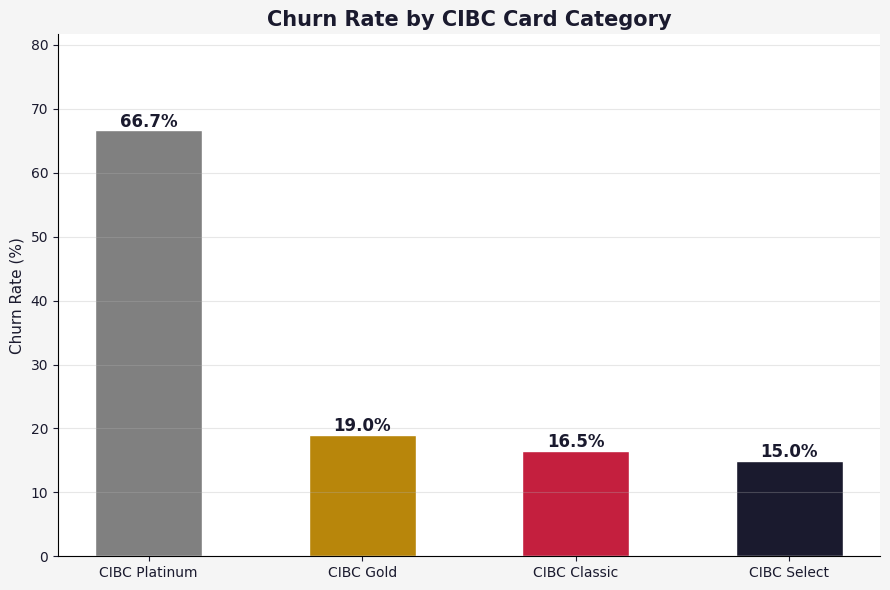

In [8]:
# ── Plot 3: Churn by Card Category ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(CIBC_GREY)

card_colors = {
    'CIBC Classic' : CIBC_RED,
    'CIBC Select'  : CIBC_NAVY,
    'CIBC Gold'    : CIBC_GOLD,
    'CIBC Platinum': '#808080'
}

card_churn = (df.groupby('card_category')['churn_flag']
              .mean().sort_values(ascending=False) * 100)

bars = ax.bar(card_churn.index, card_churn.values,
              color=[card_colors.get(c, CIBC_RED) for c in card_churn.index],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, card_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12,
            fontweight='bold', color=CIBC_NAVY)

ax.set_title('Churn Rate by CIBC Card Category', fontsize=15, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, card_churn.max() + 15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../screenshots/03_churn_by_card.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5️⃣ Age Group Analysis
> **Key Finding:** Customers aged 65+ have the highest churn rate (25%), 
> nearly double that of the 26-35 age group (13.4%). This suggests older 
> customers may be switching to simpler banking products or competitors 
> offering senior-focused benefits.

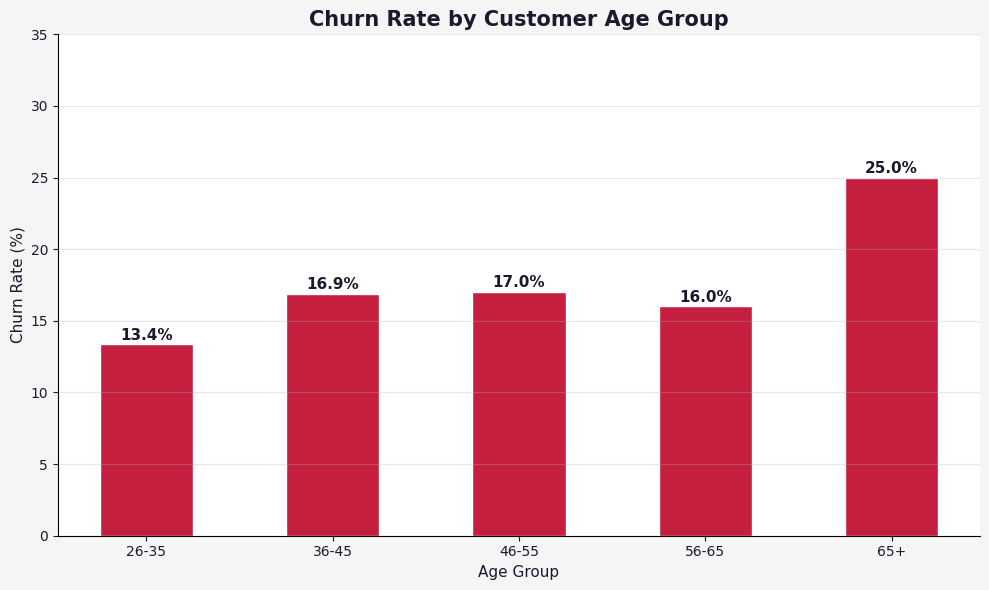

In [9]:
# ── Plot 4: Churn by Age Group ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(CIBC_GREY)

age_churn = (df.groupby('age_group', observed=True)['churn_flag']
             .mean() * 100)

bars = ax.bar(age_churn.index, age_churn.values,
              color=CIBC_RED, edgecolor='white', width=0.5)

for bar, val in zip(bars, age_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11,
            fontweight='bold', color=CIBC_NAVY)

ax.set_title('Churn Rate by Customer Age Group', fontsize=15, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, age_churn.max() + 10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../screenshots/04_churn_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6️⃣ Transaction Behaviour Analysis
> **Key Finding:** Churned customers have significantly **lower** 
> transaction amounts and counts compared to retained customers. 
> This is a strong early warning signal — declining transaction 
> activity is a leading indicator of churn risk.

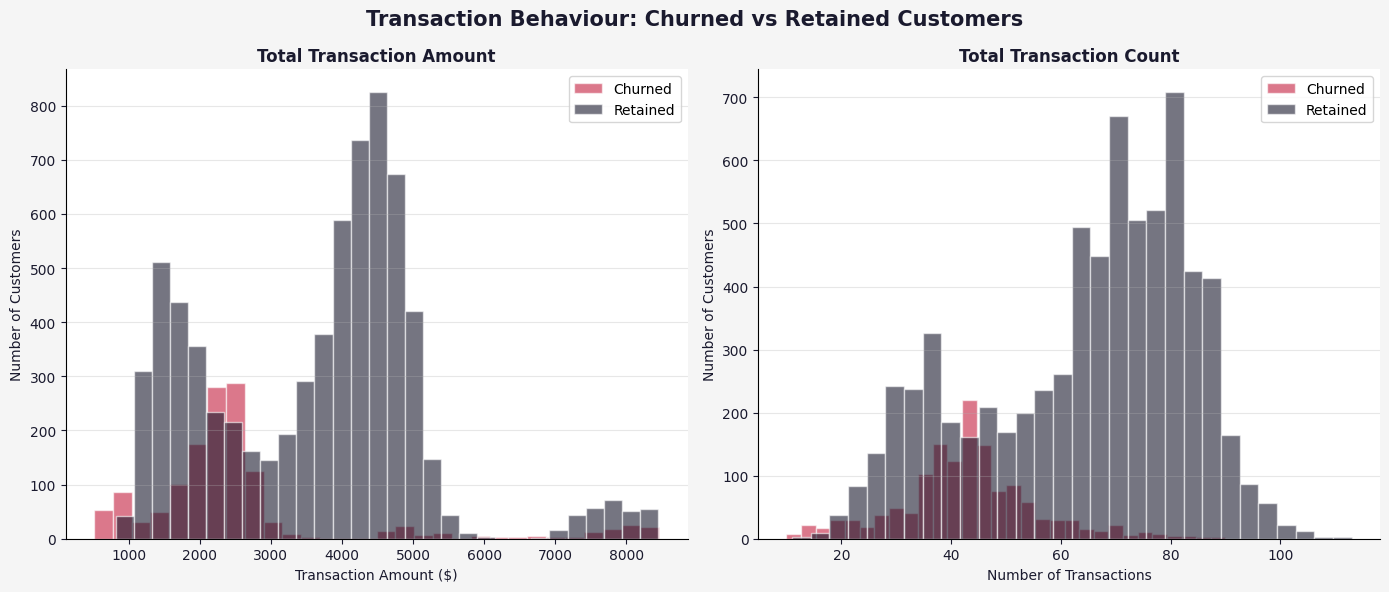

In [10]:
# ── Plot 5: Transaction Behaviour ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(CIBC_GREY)
fig.suptitle('Transaction Behaviour: Churned vs Retained Customers',
             fontsize=15, fontweight='bold', color=CIBC_NAVY)

for flag, label, color in zip(
        ['Churned','Retained'], ['Churned','Retained'], [CIBC_RED, CIBC_NAVY]):
    axes[0].hist(df[df['attrition_flag']==flag]['total_trans_amt'],
                 bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[1].hist(df[df['attrition_flag']==flag]['total_trans_ct'],
                 bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

for ax, title, xlabel in zip(axes,
    ['Total Transaction Amount', 'Total Transaction Count'],
    ['Transaction Amount ($)', 'Number of Transactions']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Number of Customers', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../screenshots/05_transaction_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7️⃣ Correlation Heatmap
> **Key Finding:** `total_trans_ct` and `total_trans_amt` are strongly 
> correlated with each other and **negatively** correlated with churn. 
> `months_inactive_12_mon` and `contacts_count_12_mon` show **positive** 
> correlation with churn — inactive customers who contact support frequently 
> are most at risk.

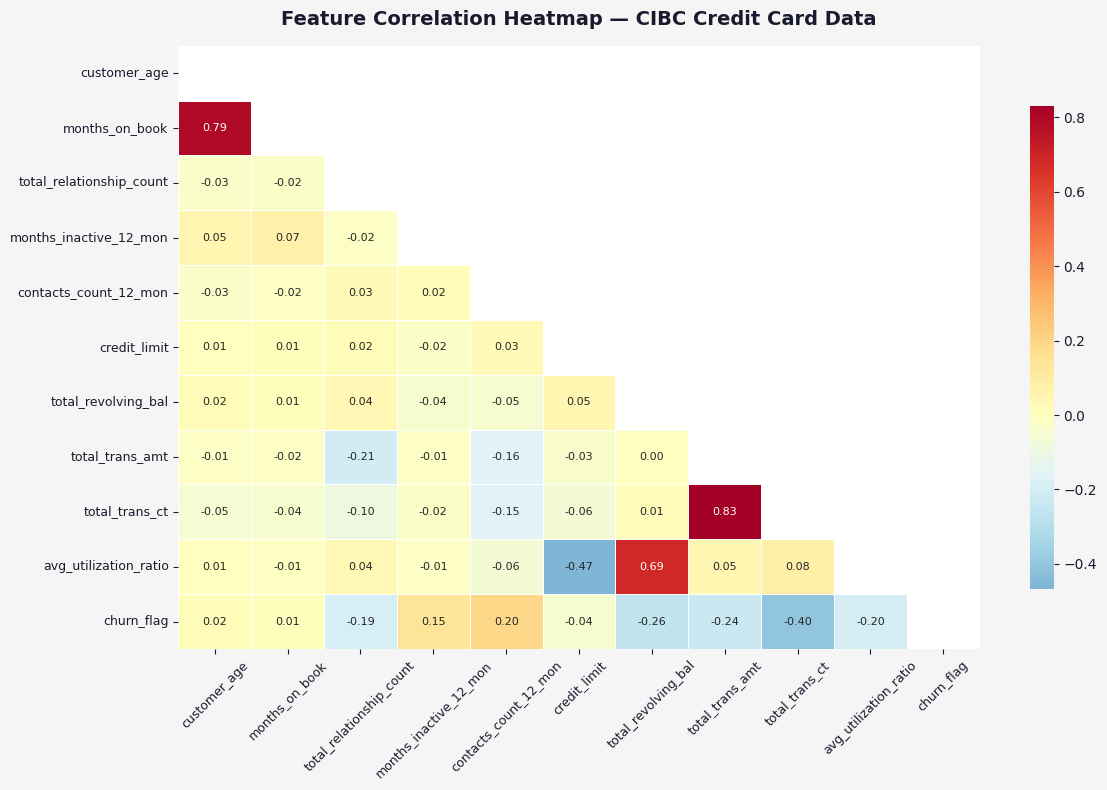

In [11]:
# ── Plot 6: Correlation Heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(CIBC_GREY)

numeric_cols = [
    'customer_age', 'months_on_book', 'total_relationship_count',
    'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit',
    'total_revolving_bal', 'total_trans_amt', 'total_trans_ct',
    'avg_utilization_ratio', 'churn_flag'
]

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap — CIBC Credit Card Data',
             fontsize=14, fontweight='bold', color=CIBC_NAVY, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('../screenshots/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8️⃣ Key Insights & Business Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | 65+ age group has 25% churn rate | Launch senior loyalty rewards program |
| 2 | Low transaction customers churn more | Trigger engagement campaigns when transactions drop |
| 3 | Inactive 3+ months = high churn risk | Automated re-engagement emails at 2 month mark |
| 4 | CIBC Gold has 19% churn vs 15% Select | Review Gold card benefits & fee structure |
| 5 | High contact count = churn signal | Improve first-call resolution & self-serve options |

---

## ✅ Summary Statistics

In [13]:
# ── Final Summary Stats ───────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total Customers', 'Churned', 'Retained',
        'Churn Rate', 'Avg Credit Limit',
        'Avg Transaction Amount', 'Avg Utilization Ratio',
        'Avg Tenure (months)'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['churn_flag'].sum():,}",
        f"{(df['churn_flag']==0).sum():,}",
        f"{df['churn_flag'].mean()*100:.2f}%",
        f"${df['credit_limit'].mean():,.0f}",
        f"${df['total_trans_amt'].mean():,.0f}",
        f"{df['avg_utilization_ratio'].mean()*100:.1f}%",
        f"{df['months_on_book'].mean():.1f}"
    ]
})

summary.style.set_properties(**{
    'background-color': '#F5F5F5',
    'color': '#1A1A2E',
    'font-weight': 'bold',
    'border': '1px solid #C41F3E'
}).hide(axis='index')

Metric,Value
Total Customers,"8,418"
Churned,"1,391"
Retained,"7,027"
Churn Rate,16.52%
Avg Credit Limit,"$5,908"
Avg Transaction Amount,"$3,460"
Avg Utilization Ratio,30.8%
Avg Tenure (months),36.0
